# SCIPE Workshop — 3D Latent Diffusion for Fracture Networks (on Koa)

In this hands-on notebook you will run a **3D Latent Diffusion Model (LDM)** that
generates realistic **discrete fracture networks (DFNs)** on a $32^3$ voxel grid,
and **condition** the generation on sparse **well observations** ("hard data").

**What is a Latent Diffusion Model?** Three trained pieces work together:

| piece | role |
|---|---|
| **VAE** | compresses a $32^3$ binary fracture volume into a small $8^3$ *latent* code (and back) |
| **Diffusion denoiser** (`Unet_SR`) | learns to turn Gaussian noise into a valid *latent* code, step by step |
| **CondEncoder** | turns sparse well observations into a *context* that steers the denoiser |

Generating = sample noise → denoise into a latent → VAE-decode into a $32^3$ DFN.
**Hard-data conditioning** = at every denoising step, (a) the context nudges the
model (classifier-free guidance, `w_cfg`) and (b) a gradient pulls the decoded
volume to match the observed well voxels (DPS, `w_dps`). The result: many
different realizations that **all honor the wells** but vary away from them.

### Roadmap  ( 🟢 RUN  /  📄 SHOW-ONLY )
1. 🟢 Load fracture dataset  2. 🟢 Visualize geometries  3. 🟢 Dataset/DataLoader
4. 🟢 Define the models  5. 📄 Training code (skipped — takes hours)
6. 🟢 Load pretrained checkpoints  7. 🟢 Generate (well-conditioned)
8. 🟢 Evaluate  9. 📄 Run full training on Koa

> This notebook runs from the `SCIPE_workshop/` folder and is **self-contained**:
> it imports only from the local `models/` package and `scipe_helpers.py`.

In [1]:
# --- setup (RUN) ---
import numpy as np, torch, yaml, time
import matplotlib.pyplot as plt

from scipe_helpers import (
    load_yaml, load_vae, load_ldm_and_encoder,
    build_well_inputs_3d, generate_conditioned, generate_unconditional, verify_hard_data,
    reconstruct_binary, render_planes, render_voxels,
    wells_and_obs, plot_realizations_triptych, plot_stats_figure,
)

# On a shared GPU node you can pin a specific card, e.g. "cuda:1".
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CKPT   = "checkpoints"
DATA   = "data/binary3d_subset.npy"
print("torch", torch.__version__, "| device:", DEVICE)

/home/jiaweish/anaconda3/envs/pytorch/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 1.13.1 | device: cuda


## 1. Load the fracture dataset  🟢 RUN

We ship a small **held-out** subset of 600 binary volumes (never seen during
training). Each volume is $32\times32\times32$; a voxel is `1` where a fracture
passes through it, `0` (matrix) otherwise. These binary volumes were obtained by
thresholding a distance field at 0.5.

In [2]:
X = np.load(DATA)                      # (600, 32, 32, 32) uint8, held-out
print("volumes :", X.shape, X.dtype)
print("values  :", np.unique(X), "  (0 = matrix, 1 = fracture)")
print(f"fracture volume fraction: {(X > 0.5).mean() * 100:.1f}%")

volumes : (600, 32, 32, 32) uint8
values  : [0 1]   (0 = matrix, 1 = fracture)
fracture volume fraction: 25.4%


## 2. Visualize fracture geometries  🟢 RUN

We show each real network two ways: the **raw voxel occupancy** the model
actually sees (a voxel is `1` where a fracture passes through it), and the
**fitted fracture planes** — the paper's DFN representation, obtained by fitting
planes to those voxels (local-PCA normals + RANSAC + convex-hull polygons).
Voxels on top, the DFN planes below. (No isosurface.)

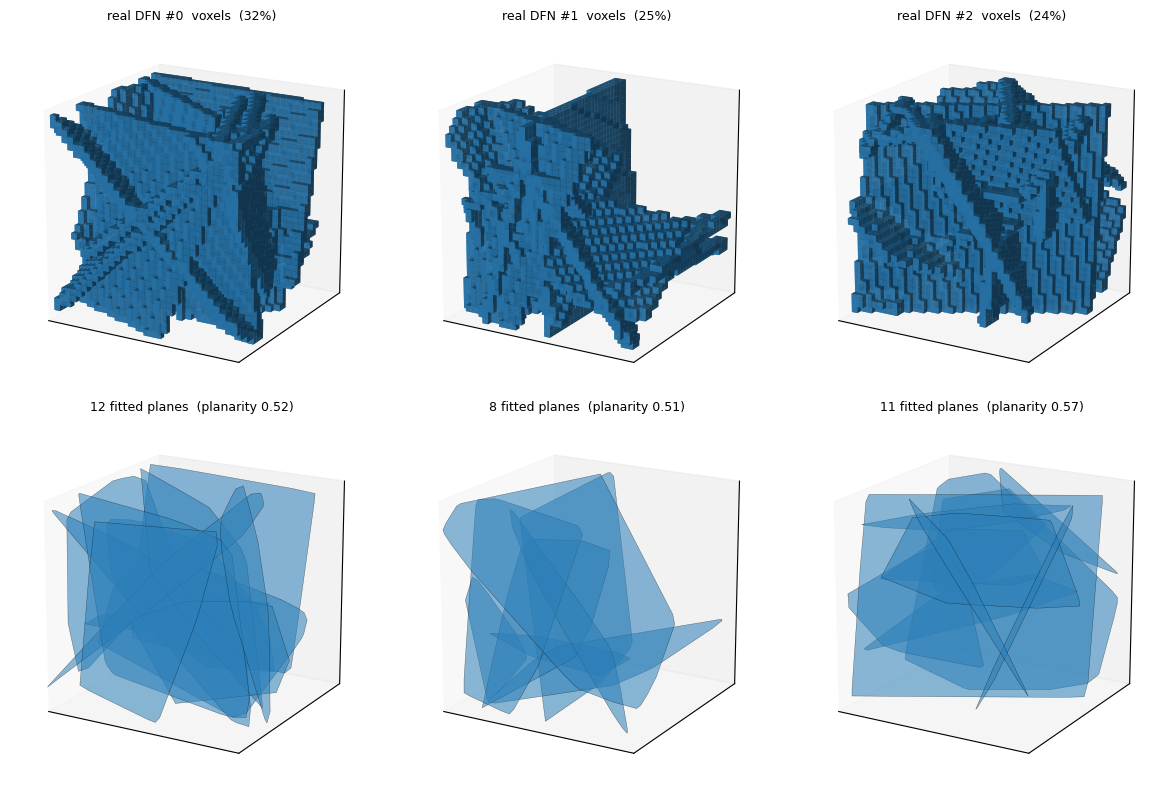

In [3]:
# Real networks shown two ways: raw voxel occupancy (top) and the fitted
# fracture PLANES (bottom, the paper's DFN representation).  No isosurface.
fig = plt.figure(figsize=(12, 8))
for i in range(3):
    v = X[i].astype(float)
    polys, planarity = reconstruct_binary(v)
    ax = fig.add_subplot(2, 3, i + 1, projection="3d")
    render_voxels(ax, v, f"real DFN #{i}  voxels  ({(v > 0.5).mean() * 100:.0f}%)",
                  "#2c7fb8", alpha=0.85)
    ax = fig.add_subplot(2, 3, i + 4, projection="3d")
    render_planes(ax, polys, f"{len(polys)} fitted planes  (planarity {planarity:.2f})",
                  "#2c7fb8")
plt.tight_layout(); plt.show()

## 3. Prepare a PyTorch Dataset / DataLoader  🟢 RUN

Exactly what training would use: wrap the volumes as `(N, 1, 32, 32, 32)` float
tensors and batch them. (We only *iterate* it here — no training in the workshop.)

In [4]:
from torch.utils.data import TensorDataset, DataLoader

tensor  = torch.tensor(X.astype(np.float32)).unsqueeze(1)   # (N,1,32,32,32)
dataset = TensorDataset(tensor)
loader  = DataLoader(dataset, batch_size=8, shuffle=True)

batch, = next(iter(loader))
print("one batch:", tuple(batch.shape), batch.dtype,
      "| value range", float(batch.min()), "-", float(batch.max()))

one batch: (8, 1, 32, 32, 32) torch.float32 | value range 0.0 - 1.0


## 4. Define the models  🟢 RUN

Build the three architectures (weights come later, in step 6). Notice how small
the latent is — that is what makes diffusion cheap here.

In [5]:
from models.dim3.VAE_Modules import UNetVAE
from models.dim3.Modules import Unet_SR
from models.dim3.CondEncoder import CondEncoder3D

vcfg0 = load_yaml(f"{CKPT}/VAE_config.yml")
vae0 = UNetVAE(latent_dim=vcfg0["latent_dim"], out_channels=vcfg0["latent_channels"],
               dim=vcfg0["dim"], in_channels=vcfg0["channels"], dim_mults=vcfg0["dim_mults"],
               Downsample_type=vcfg0["Downsample_type"], flatten=vcfg0["flatten"],
               output_activation=vcfg0["output_activation"])
ldm0 = Unet_SR(dim=128, channels=1, dim_mults=(1, 2, 4, 8))   # latent denoiser
enc0 = CondEncoder3D(hidden_dim=32, image_size=32)            # wells -> context

for name, m in [("VAE (compress)", vae0), ("Diffusion denoiser", ldm0), ("CondEncoder", enc0)]:
    print(f"{name:20s} {sum(p.numel() for p in m.parameters()) / 1e6:6.1f} M parameters")

with torch.no_grad():
    z = vae0.reparameterize(*vae0.encode(tensor[:1]))
print("\na 32x32x32 volume compresses to latent shape:", tuple(z.shape[1:]))

Sigmoid
VAE (compress)         16.4 M parameters
Diffusion denoiser    386.0 M parameters
CondEncoder             0.1 M parameters

a 32x32x32 volume compresses to latent shape: (1, 8, 8, 8)


## 5. Training code  📄 SHOW-ONLY — do **not** run in the workshop

Full training takes **hours** on a GPU. Below is the *structure* of the two
training stages so you can read it; we load pretrained weights instead (step 6).

**Stage A — train the VAE** to compress & reconstruct volumes:
```python
vae = UNetVAE(...).to(device)
opt = torch.optim.Adam(vae.parameters(), lr=1e-4)
for epoch in range(600):
    for (x,) in loader:
        x = x.to(device)
        recon, mu, logvar = vae(x)
        recon_loss = tversky_loss(recon, x)                 # class-balanced overlap
        kl = -0.5 * torch.mean(1 + logvar - mu**2 - logvar.exp())
        loss = recon_loss + 1e-4 * kl                       # kld_weight = 1e-4
        opt.zero_grad(); loss.backward(); opt.step()
```

**Stage B — train the diffusion denoiser + CondEncoder** in the *frozen* VAE
latent, with well conditioning (EDM formulation):
```python
from models.dim3.Sampling_EDM import EDMPrecondCond, edm_loss_cond
import random

precond = EDMPrecondCond(Unet_SR(dim=128, channels=1, dim_mults=(1,2,4,8)),
                         sigma_data=SIGMA_DATA).to(device)
enc = CondEncoder3D(hidden_dim=32, image_size=32).to(device)
opt = torch.optim.Adam(list(precond.parameters()) + list(enc.parameters()), lr=2e-4)

for epoch in range(500):
    for (x,) in loader:
        x = x.to(device)
        n_w = random.randint(1, 2)                            # paper: 1-2 wells per image
        value_map, mask = build_well_inputs_3d(x, n_wells=n_w, device=device)  # random wells
        ctx = enc(value_map, mask)
        if random.random() < 0.1:                 # 10% CFG dropout -> unconditional path
            ctx = None
        with torch.no_grad():
            z = encode(vae, vcfg, x) - LATENT_MEAN            # frozen VAE latent
        loss = edm_loss_cond(precond, z, ctx)                 # EDM denoising loss
        opt.zero_grad(); loss.backward(); opt.step()
    ema.update(precond.model)                                 # EMA weights are what we sample
```
The pretrained checkpoints you load next were produced by exactly this recipe
(run at scale on Koa — see step 9).

## 6. Load the pretrained checkpoints  🟢 RUN

`LDM_ema.pt` are the **EMA** weights of the denoiser (what we sample from);
`latent_stats.yml` stores the latent normalization the sampler needs.

In [6]:
vae, vcfg = load_vae(f"{CKPT}/VAE_config.yml", f"{CKPT}/UnetVAE.pt", DEVICE)
ldm, enc  = load_ldm_and_encoder(f"{CKPT}/LDM_ema.pt", f"{CKPT}/CondEncoder_ema.pt", DEVICE)

st = load_yaml(f"{CKPT}/latent_stats.yml")
LATENT_MEAN, SIGMA_DATA, LATENT_SHAPE = st["latent_mean"], st["sigma_data"], tuple(st["latent_shape"])
print("checkpoints loaded.")
print("latent shape:", LATENT_SHAPE, "| sigma_data:", round(SIGMA_DATA, 3))

Sigmoid
checkpoints loaded.
latent shape: (1, 8, 8, 8) | sigma_data: 1.002


### Real vs generated — both as fitted fracture planes

Before conditioning on wells, a quick check that the loaded model produces
realistic geometry on its own. We draw a few **unconditional** samples (pure
prior, no wells) and fit fracture planes to them, side by side with real
held-out networks fitted the same way. Real is grey (top), generated is blue
(bottom) — the same plane representation, so the two are directly comparable.

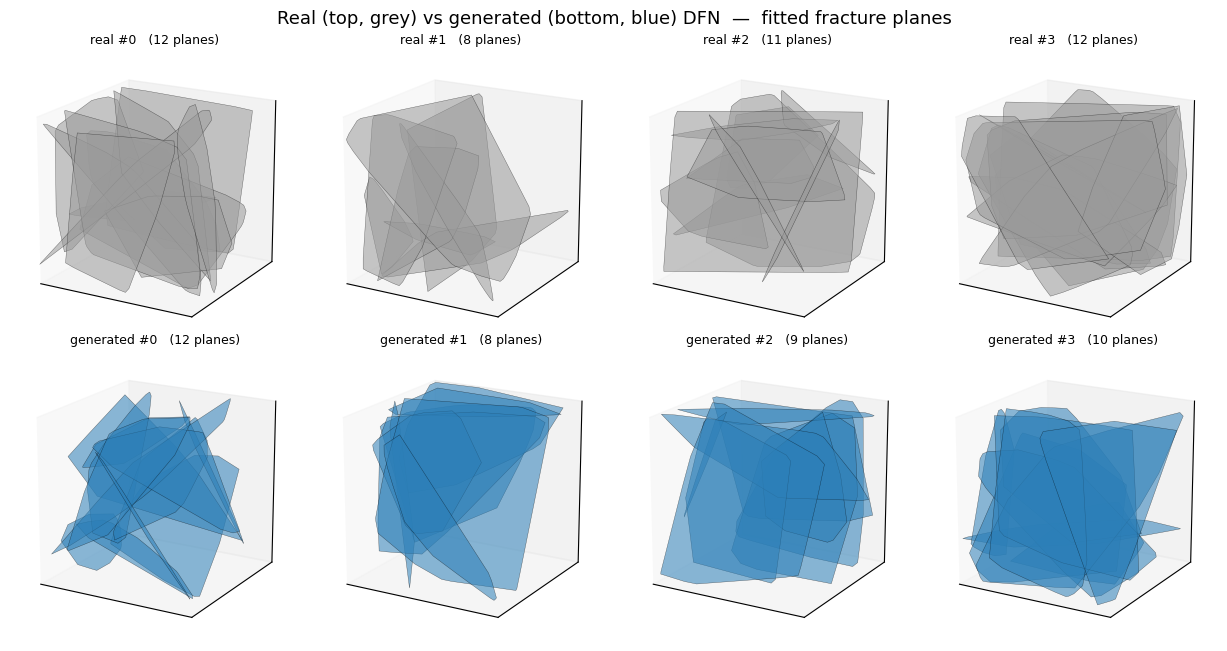

In [7]:
# Real vs generated DFN, BOTH shown as fitted fracture planes.
# Generation here is UNCONDITIONAL (context=None, w_cfg=1, w_dps=0): the model's
# pure prior, no wells -- so the comparison is purely about geometry/representation.
torch.manual_seed(0)
N_CMP = 4
gu = generate_unconditional(ldm, vae, vcfg, n_samples=N_CMP, device=DEVICE,
                            latent_mean=LATENT_MEAN, sigma_data=SIGMA_DATA,
                            latent_shape=LATENT_SHAPE, num_steps=32)
gen_unc = (gu[:, 0].detach().cpu().numpy() > 0.5).astype(float)

fig = plt.figure(figsize=(3.1 * N_CMP, 6.6))
for j in range(N_CMP):
    rp, rpl = reconstruct_binary(X[j].astype(float))
    ax = fig.add_subplot(2, N_CMP, j + 1, projection="3d")
    render_planes(ax, rp, f"real #{j}   ({len(rp)} planes)", "#9a9a9a")
    gp, gpl = reconstruct_binary(gen_unc[j])
    ax = fig.add_subplot(2, N_CMP, N_CMP + j + 1, projection="3d")
    render_planes(ax, gp, f"generated #{j}   ({len(gp)} planes)", "#2c7fb8")
fig.suptitle("Real (top, grey) vs generated (bottom, blue) DFN  —  fitted fracture planes",
             fontsize=13)
plt.tight_layout(); plt.show()

## 7. Generate well-conditioned fracture networks  🟢 RUN

The workflow a geoscientist cares about: **you have a few boreholes**, and you
want many plausible 3D fracture networks that are **consistent with what the wells
saw**. We

1. take a held-out volume as ground truth,
2. "drill" a couple of vertical boreholes and record the fracture/matrix voxels along them,
3. generate several realizations conditioned on those observations.

> The paper conditions on **1-2 wells**, and the shipped model was trained that
> way, so we drill **2** boreholes here (conditioning on far more wells than a
> model was trained with is out-of-distribution and degrades the result).

In [8]:
# 7a. pick a reference volume and drill wells  (paper setting: 1-2 wells)
torch.manual_seed(0)
REF_IDX  = 3
N_WELLS  = 2
ref = torch.tensor(X[REF_IDX:REF_IDX + 1].astype(np.float32), device=DEVICE).unsqueeze(1)
value_map, mask = build_well_inputs_3d(ref, n_wells=N_WELLS, device=DEVICE, beta=1.0)
wells, obs_f = wells_and_obs(value_map, mask)   # (h,w) footprints + fracture-obs voxels
print(f"{int(mask.sum())} observed voxels along {N_WELLS} boreholes "
      f"({len(obs_f)} of them intersect fractures)")

64 observed voxels along 2 boreholes (22 of them intersect fractures)


In [9]:
# 7b. conditioned generation  (CFG w_cfg + DPS w_dps).  ~15-30 s on a GPU.
W_CFG, W_DPS, STEPS, N = 3.0, 4.0, 32, 4     # recommended operating point
t0 = time.time()
gen = generate_conditioned(ldm, enc, vae, vcfg, value_map, mask, n_samples=N, device=DEVICE,
                           latent_mean=LATENT_MEAN, sigma_data=SIGMA_DATA, latent_shape=LATENT_SHAPE,
                           w_cfg=W_CFG, w_dps=W_DPS, num_steps=STEPS)
gen_vol = (gen[:, 0].detach().cpu().numpy() > 0.5).astype(float)
print(f"generated {gen_vol.shape[0]} realizations in {time.time() - t0:.1f}s")

generated 4 realizations in 6.1s


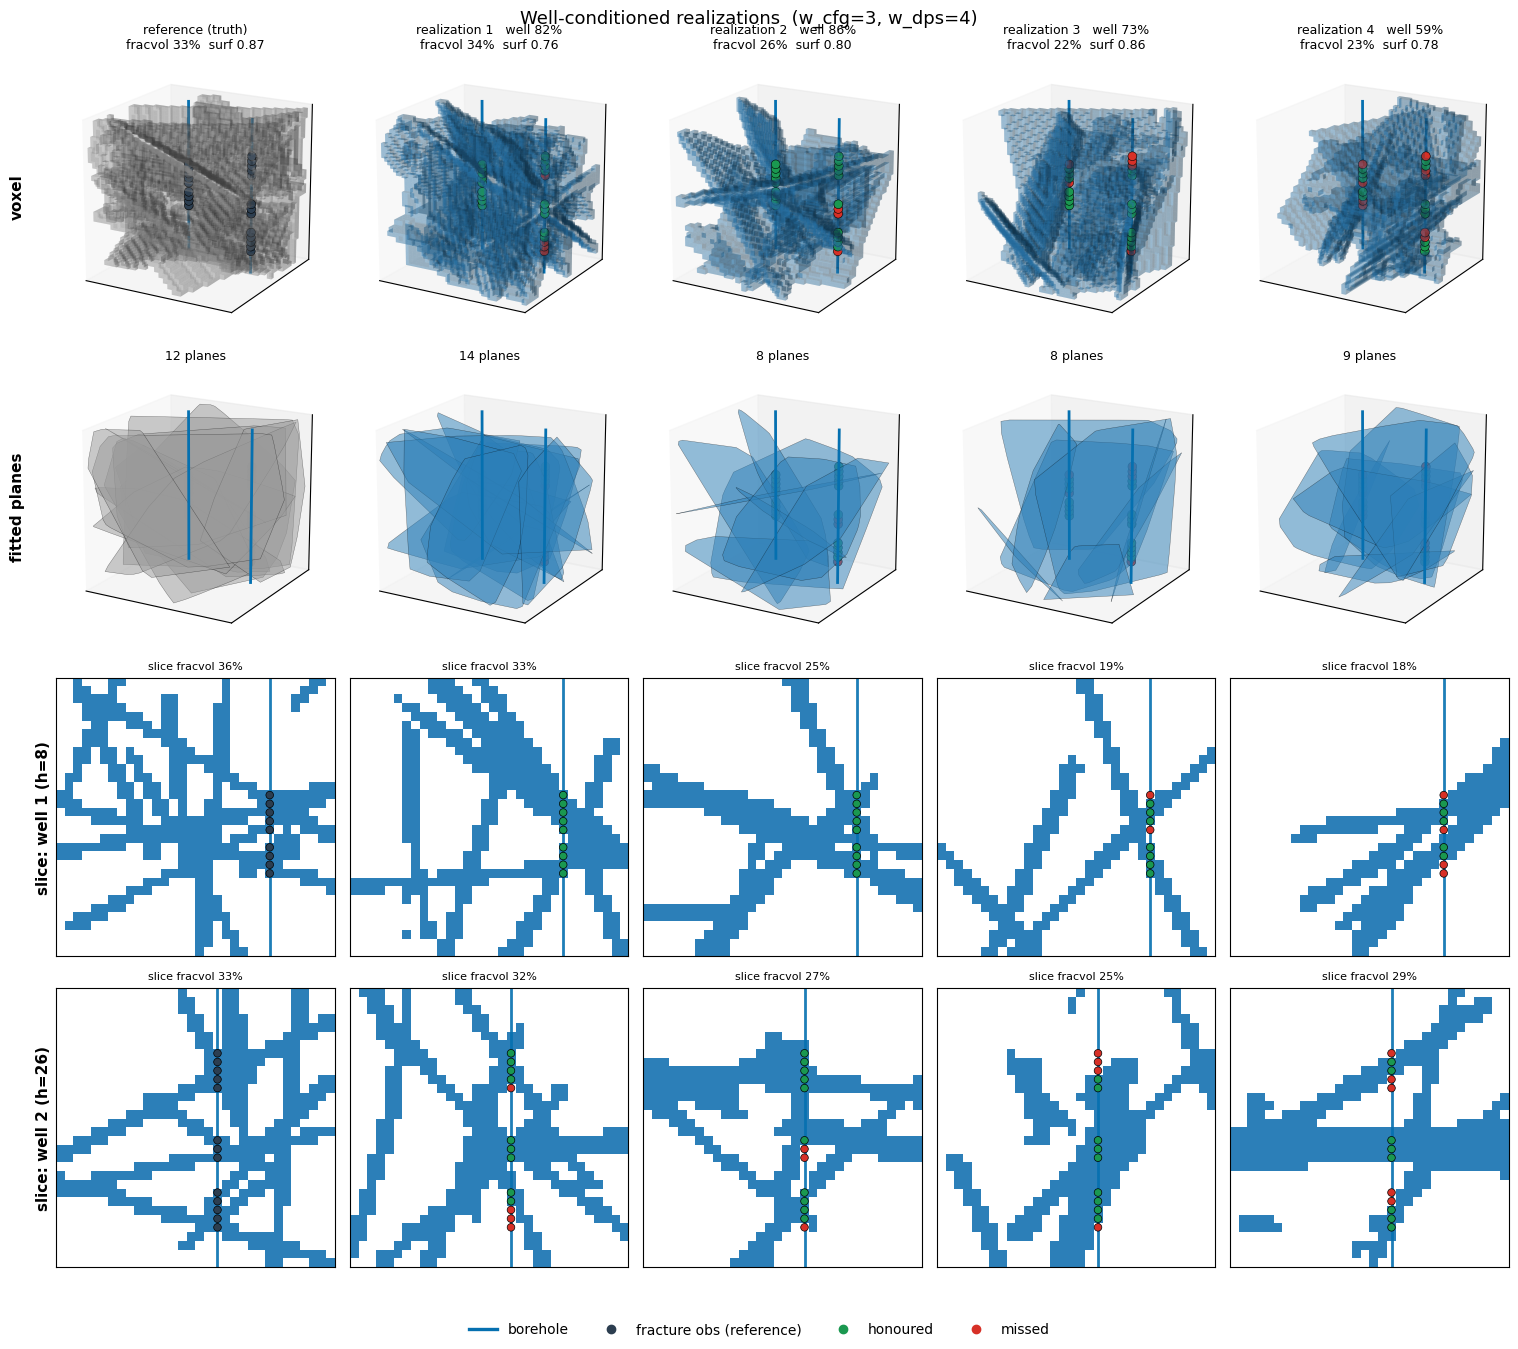

In [10]:
# 7c. reference vs realizations, paper Figure-7 style: each column shown three ways
#     -- raw voxels, fitted DFN planes, and one borehole cross-section per well.
#     Well markers: green = fracture observation honoured, red = missed.
gens = [gen_vol[i] for i in range(gen_vol.shape[0])]
fig = plot_realizations_triptych(X[REF_IDX].astype(float), gens, wells, obs_f)
fig.suptitle(f"Well-conditioned realizations  (w_cfg={W_CFG:g}, w_dps={W_DPS:g})",
             fontsize=13)
plt.show()

## 8. Evaluate the generated geometries  🟢 RUN

Two things matter for conditioned generation:

- **Hard-data satisfaction** — do the realizations reproduce what the wells saw?
  (the conditioning-specific metric)
- **Statistical realism** — is the overall fracture density / porosity right?

In [11]:
# 8a. hard-data satisfaction at well voxels (fracture vs matrix, reported separately)
tmf = tmb = tnf = tnb = 0
for i in range(gen.shape[0]):
    mf, mb, nf, nb = verify_hard_data(gen[i:i + 1], value_map, mask)
    tmf += mf; tmb += mb; tnf += nf; tnb += nb
print(f"hard-data satisfaction:  fracture {100 * tmf / max(tnf, 1):.1f}%   "
      f"matrix {100 * tmb / max(tnb, 1):.1f}%")

# 8b. density realism
print(f"fracture volume fraction: generated {gen_vol.mean() * 100:.1f}%  |  "
      f"real (held-out) {(X > 0.5).mean() * 100:.1f}%")

hard-data satisfaction:  fracture 75.0%   matrix 86.9%
fracture volume fraction: generated 26.2%  |  real (held-out) 25.4%


64 unconditional samples in 11.9s; computing PoreSpy stats vs 200 real ...


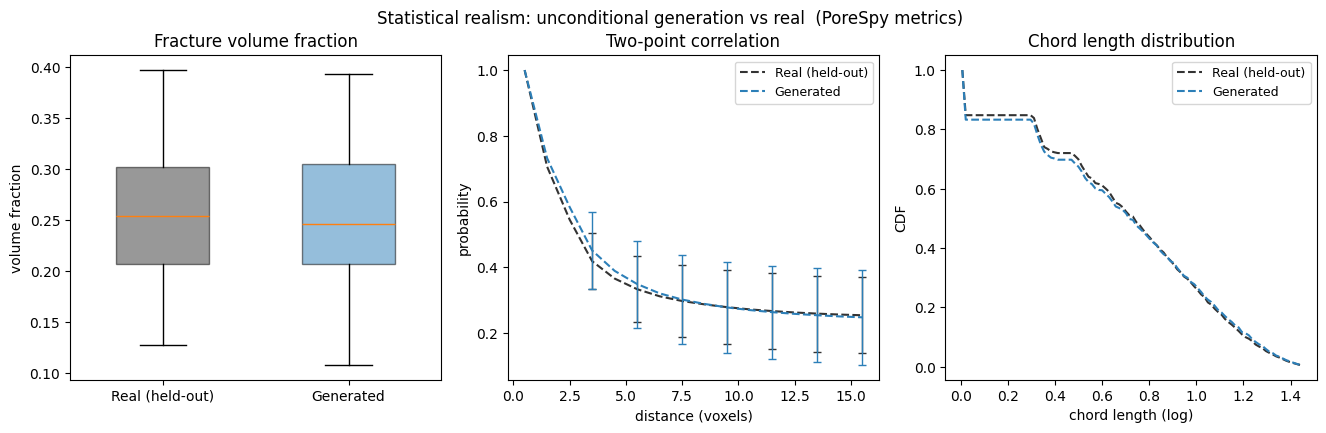

In [12]:
# 8c. statistical realism, paper Figure-3 style: three PoreSpy metrics comparing
#     generated realizations against held-out real networks -- fracture volume
#     fraction (box), two-point correlation, and chord-length CDF.
#     Like paper1's Figure 3, the comparison is UNCONDITIONAL (context=None,
#     w_cfg=1, w_dps=0): we compare the model's learned PRIOR against real, so the
#     statistics reflect the whole distribution -- NOT one well configuration. Using
#     conditioned samples here (all pulled toward the same 2 wells) would bias the
#     stats and collapse diversity. More samples -> tighter curves / CIs.
try:
    import porespy as ps  # noqa: F401
    N_STATS   = 64                                    # unconditional realizations
    N_REAL    = 200                                   # held-out real networks
    torch.manual_seed(1)
    t0 = time.time()
    gs = generate_unconditional(ldm, vae, vcfg, n_samples=N_STATS, device=DEVICE,
                                latent_mean=LATENT_MEAN, sigma_data=SIGMA_DATA,
                                latent_shape=LATENT_SHAPE, num_steps=STEPS)
    gen_stats  = (gs[:, 0].detach().cpu().numpy() > 0.5).astype(np.float32)
    real_stats = (X[:N_REAL] > 0.5).astype(np.float32)
    print(f"{N_STATS} unconditional samples in {time.time() - t0:.1f}s; "
          f"computing PoreSpy stats vs {N_REAL} real ...")
    fig = plot_stats_figure(real_stats, gen_stats)
    fig.suptitle("Statistical realism: unconditional generation vs real  (PoreSpy metrics)", y=1.02)
    plt.show()
except ImportError:
    print("porespy not installed - skipping statistics figure (see environment.yml)")

> **Tip:** raise `W_DPS` (e.g. 6-8) or `STEPS` (e.g. 48) in step 7b to push
> hard-data satisfaction higher, at the cost of a little more compute. Try it and
> re-run step 8 to see the trade-off.

## 9. Run the full training on Koa  📄 SHOW-ONLY

Training from scratch is a batch job. On **Koa** (SLURM + `module load
lang/Anaconda3` + a conda env), submit `koa_train.sbatch`:

```bash
# one-time: create the environment
module load lang/Anaconda3
conda env create -f environment.yml      # creates env "scipe-ldm"

# submit the training job
sbatch koa_train.sbatch                   # edit --account / --partition first!
squeue -u $USER                           # watch it
tail -f slurm-<jobid>.out                 # follow the log
```

`koa_train.sbatch` (shipped in this folder) looks like:
```bash
#!/bin/bash
#SBATCH --job-name=scipe-ldm
#SBATCH --account=YOUR_ACCOUNT       # <-- fill in
#SBATCH --partition=YOUR_GPU_PART    # <-- fill in (a GPU partition)
#SBATCH --gres=gpu:1
#SBATCH --cpus-per-task=8
#SBATCH --mem=64G
#SBATCH --time=12:00:00
#SBATCH --output=slurm-%j.out

module purge
module load lang/Anaconda3
source activate scipe-ldm

# Stage A: VAE   (skip if you already have checkpoints/UnetVAE.pt)
python train_vae.py --config configs/3d_vae_binfromtudf.yml --ndim 3
# Stage B: hard-data (1-2 well) conditioned LDM
python train_ldm_harddata_edm_3d.py     --config configs/3d_harddata_binfromtudf_w12_lambda_cons0.yml
```
(The training scripts + `configs/` live in the research repo, not this folder;
`koa_train.sbatch` shows the full job.)

**Key points for students**
- Ask for a **GPU** (`--gres=gpu:1`) and a realistic **wall time** (`--time`).
- Keep large data/checkpoints on the shared filesystem, not in `$HOME` quotas.
- The interactive notebook is for *inference*; heavy *training* always goes
  through `sbatch`, never on the login node.

Congratulations — you have run a 3D latent diffusion model end to end and
conditioned it on well data. 🎉